In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class BasicNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16), requires_grad=False)

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

In [ ]:
input_doses = torch.linspace(start=0, end=1, steps=11)
input_doses

In [ ]:
model = BasicNN() # init
output_values = model(input_doses) # forward
output_values

In [ ]:
plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values, linewidths=1)
plt.plot(input_doses, output_values)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [ ]:
class BasicNN_train(nn.Module):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

In [ ]:
model = BasicNN_train()
output_values = model(input_doses)
output_values

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(3,3))
sns.lineplot(x=input_doses,
             y=output_values.detach(),
             color='green', linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

train

In [ ]:
inputs = torch.tensor([0., 0.5, 1.,])
labels = torch.tensor([0., 1., 0.,])

In [ ]:
optimizer = SGD(model.parameters(), lr=0.1)
print(f"Final bias, before optimization: {model.final_bias.data}")

In [ ]:
for epoch in range(100):

    total_loss = 0

    for iteration in range(len(inputs)):

        input_i = inputs[iteration]
        labels_i = labels[iteration] # y true

        output_i = model(input_i) # y pred

        loss = (output_i - labels_i) ** 2 # SR

        loss.backward() # d_loss_1 / d_b_final # add to the previous derivitive!
        # optimizer.step() # update final bias
        # optimizer.zero_grad() # reset accumulation

        total_loss += float(loss)


    output_values = model(input_doses)
    sns.set(style="whitegrid")
    plt.figure(figsize=(3,3))
    sns.lineplot(x=input_doses,
                y=output_values.detach(),
                color='green', linewidth=2.5)
    plt.ylabel("Effectiveness")
    plt.xlabel("Dose")
    plt.show()

    if total_loss < 0.0001:
        print(f"Num steps = {epoch}")
        break

    optimizer.step() # update final bias
    optimizer.zero_grad() # reset accumulation

    print(f"step: {epoch}, Final Bias: {model.final_bias.data:.5}, total_loss = {total_loss:.4}")



In [ ]:
print(f"Final bias , after optimization: {model.final_bias.data:.3}")

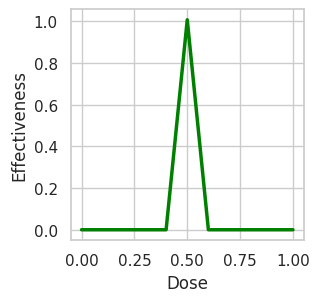

In [13]:
output_values = model(input_doses)

sns.set(style="whitegrid")
plt.figure(figsize=(3,3))
sns.lineplot(x=input_doses,
             y=output_values.detach(),
             color='green', linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

# lightning

In [14]:
import lightning as L
from torch.utils.data import TensorDataset, DataLoader # for large datasets
from lightning.pytorch.tuner import Tuner

In [15]:
class BasicLightning(L.LightningModule):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16), requires_grad=False)

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

Test

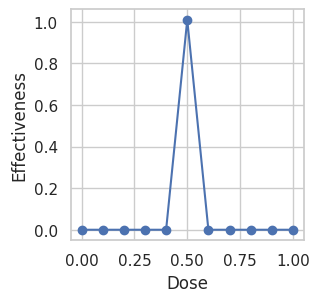

In [16]:
input_doses = torch.linspace(start=0, end=1, steps=11)
model = BasicLightning() # init
output_values = model(input_doses) # forward

plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values, linewidths=1)
plt.plot(input_doses, output_values)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [17]:
class BasicLightningTrain(L.LightningModule):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

        self.learning_rate = 0.1 # new

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

    # LR will be improved on the fly!
    def configure_optimizers(self):
        return SGD(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = (output_i - label_i) ** 2
        return loss

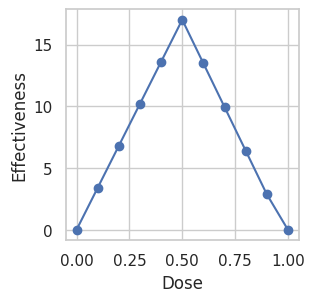

In [18]:
model = BasicLightningTrain() # init
output_values = model(input_doses) # forward

plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values.detach(), linewidths=1) # detach - only values without grads
plt.plot(input_doses, output_values.detach())
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [19]:
dataset = TensorDataset(inputs, labels)

# DataLoader useful for lots of data:
# 1. make it easy to access the data in batches
# 2. easy to shuffle the data each epoch
# 3. easy to use small fraction of the data for quick train for debug
dataloader = DataLoader(dataset)

In [20]:
trainer = L.Trainer(max_epochs=34, accelerator='auto', devices='auto')
tuner = Tuner(trainer)

lr_find_results = tuner.lr_find(model,
                                train_dataloaders=dataloader,
                                # min_lr=0.001,
                                # max_lr=1.0,
                                # early_stop_threshold=None
                                )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
2026-03-24 15:57:21.872079: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 15:57:23.929355: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 2 steps due to diverging loss.
Restoring states from the checkpoint path at /root/dvir.hershkovits/CV/CNN/.lr_find_41333857-9c7b-4769-8dca-28538d34bb43.ckpt
Restored all states from the checkpoint at /root/dvir.hershkovits/CV/CNN/.lr_find_41333857-9c7b-4769-8dca-28538d34bb43.ckpt
Failed to compute suggestion for learning rate because there are not enough points. Increase the loop iteration limits or the size of your dataset/dataloader.


In [21]:
# new_lr = lr_find_results.suggestion()
# print(f"lr_find() suggests {new_lr:.5f} for the LR")

In [22]:
# model.learning_rate = new_lr

Training model

In [23]:
trainer.fit(model, train_dataloaders=dataloader)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│   │ other params │ n/a  │      7 │ n/a  │   n/a │
└───┴──────────────┴──────┴────────┴──────┴───────┘

Trainable params: 1                                                                                                
Non-trainable params: 6                                                                                            
Total params: 7                                                                                                    
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=34` reached.


In [24]:
print(model.final_bias.data)

tensor(-16.0019)


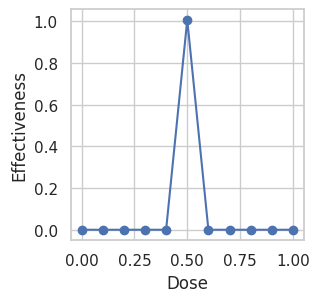

In [25]:
output_values = model(input_doses)

plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values.detach(), linewidths=1) # detach - only values without grads
plt.plot(input_doses, output_values.detach())
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()